### Setup and Configuration for Cityscapes U-Net Training

In [ ]:


import torch
import torch.nn as nn
import torch.optim as optim
import torch.cuda.amp as amp 
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms 
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
from PIL import Image
import os
import cv2 
from tqdm import tqdm 
import matplotlib.pyplot as plt
import time 
import random 
import warnings 
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'



print("Libraries imported successfully.")

# Global Configuration Parameters
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_HEIGHT = 256
IMAGE_WIDTH = 512
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
NUM_EPOCHS = 80
NUM_CITYSCAPES_CLASSES = 19 
IGNORE_INDEX = 255 

# Define the ID_TO_TRAINID mapping for Cityscapes
ID_TO_TRAINID = np.full(256, 255, dtype=np.uint8)
ID_TO_TRAINID[[7, 8, 11, 12, 13, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 31, 32, 33]] = \
    [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]

# Cityscapes training class names
CITYSCAPES_CLASS_NAMES = [
    "road", "sidewalk", "building", "wall", "fence", "pole", "traffic light",
    "traffic sign", "vegetation", "terrain", "sky", "person", "rider", "car",
    "truck", "bus", "train", "motorcycle", "bicycle"
]

# PATH CONFIGURATION 

TRAIN_IMAGES_DIR = './leftImg8bit_trainvaltest/leftImg8bit/train'
TRAIN_MASKS_DIR = './gtFine_trainvaltest/gtFine/train'
VAL_IMAGES_DIR = './leftImg8bit_trainvaltest/leftImg8bit/val'
VAL_MASKS_DIR = './gtFine_trainvaltest/gtFine/val'

# Directories for saving models and plots 
MODEL_SAVE_DIR = './saved_models'
PLOTS_SAVE_DIR = './training_plots'

# Create necessary directories if they don't exist
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(PLOTS_SAVE_DIR, exist_ok=True)

print(f"Configuration loaded. Device: {DEVICE}")
print(f"Image dimensions: {IMAGE_HEIGHT}x{IMAGE_WIDTH}")
print(f"Number of Cityscapes classes (train IDs): {NUM_CITYSCAPES_CLASSES}")
# Removed DATA_PATH as a single base, now showing explicit directories
print(f"Training Image Dir: {TRAIN_IMAGES_DIR}")
print(f"Training Mask Dir: {TRAIN_MASKS_DIR}")
print(f"Validation Image Dir: {VAL_IMAGES_DIR}")
print(f"Validation Mask Dir: {VAL_MASKS_DIR}")

# CRITICAL PATH DIAGNOSTICS 

print("\n--- Running initial path diagnostics ---")
if not os.path.exists(TRAIN_IMAGES_DIR):
    raise FileNotFoundError(
        f"ERROR: Training images directory not found: '{TRAIN_IMAGES_DIR}'. "
        "Please double-check the path relative to your notebook's location."
    )
if not os.path.exists(TRAIN_MASKS_DIR):
    raise FileNotFoundError(
        f"ERROR: Training masks directory not found: '{TRAIN_MASKS_DIR}'. "
        "Please double-check the path relative to your notebook's location."
    )
if not os.path.exists(VAL_IMAGES_DIR):
    raise FileNotFoundError(
        f"ERROR: Validation images directory not found: '{VAL_IMAGES_DIR}'. "
        "Please double-check the path relative to your notebook's location."
    )
if not os.path.exists(VAL_MASKS_DIR):
    raise FileNotFoundError(
        f"ERROR: Validation masks directory not found: '{VAL_MASKS_DIR}'. "
        "Please double-check the path relative to your notebook's location."
    )

print("All base image and mask directories confirmed to exist.")
print("--- End of initial path diagnostics ---")

Libraries imported successfully.
Configuration loaded. Device: cuda
Image dimensions: 256x512
Number of Cityscapes classes (train IDs): 19
Training Image Dir: ./leftImg8bit_trainvaltest/leftImg8bit/train
Training Mask Dir: ./gtFine_trainvaltest/gtFine/train
Validation Image Dir: ./leftImg8bit_trainvaltest/leftImg8bit/val
Validation Mask Dir: ./gtFine_trainvaltest/gtFine/val

--- Running initial path diagnostics ---
All base image and mask directories confirmed to exist.
--- End of initial path diagnostics ---


In [2]:
print("\n--- Dataset folder image count ---")

def count_images_per_city(image_root, split_name):
    print(f"\n{split_name} Image Folder Structure:")
    total_images = 0
    for city in os.listdir(image_root):
        city_path = os.path.join(image_root, city)
        if os.path.isdir(city_path):
            images = [f for f in os.listdir(city_path) if f.endswith(".png")]
            num_images = len(images)
            total_images += num_images
            print(f"  {city}: {num_images} images")
    print(f"Total {split_name} images: {total_images}")

# Count images in train and val image directories
count_images_per_city(TRAIN_IMAGES_DIR, "Training")
count_images_per_city(VAL_IMAGES_DIR, "Validation")



--- Dataset folder image count ---

Training Image Folder Structure:
  jena: 119 images
  strasbourg: 365 images
  krefeld: 99 images
  hamburg: 248 images
  zurich: 122 images
  stuttgart: 196 images
  weimar: 142 images
  erfurt: 109 images
  bremen: 316 images
  monchengladbach: 94 images
  tubingen: 144 images
  dusseldorf: 221 images
  hanover: 196 images
  cologne: 154 images
  bochum: 96 images
  ulm: 95 images
  aachen: 174 images
  darmstadt: 85 images
Total Training images: 2975

Validation Image Folder Structure:
  lindau: 59 images
  munster: 174 images
  frankfurt: 267 images
Total Validation images: 500


### Dataset and DataLoader Definition

In [ ]:

# This cell defines the custom Dataset class for Cityscapes and sets up DataLoaders.
# It now uses Albumentations for transformations and correctly handles Cityscapes paths.

class CityscapesDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None, debug_mode=False):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform
        self.debug_mode = debug_mode # New: Control internal debugging prints
        self.image_files = self._get_image_files()

        if not self.image_files:
            raise RuntimeError(
                f"No image files found in '{images_dir}'. "
                f"Please ensure images exist and are named '*_leftImg8bit.png' "
                f"within city subfolders (e.g., '{images_dir}/aachen/*.png')."
            )
        print(f"Found {len(self.image_files)} image files for this split.")


    def _get_image_files(self):
        image_files = []
        # Cityscapes images are organized in city folders (e.g., 'train/aachen', 'val/munster')
        # List city folders within the images_dir (e.g., 'aachen', 'frankfurt', etc.)
        
        # Ensure the base directory itself exists before listing contents
        if not os.path.isdir(self.images_dir):
            raise FileNotFoundError(f"Image directory does not exist: {self.images_dir}")

        for city_folder in sorted(os.listdir(self.images_dir)):
            city_path = os.path.join(self.images_dir, city_folder)
            
            if os.path.isdir(city_path): # Ensure it's a directory (skip .DS_Store, etc.)
                # Filter for _leftImg8bit.png files and sort for consistency
                current_city_images = sorted([f for f in os.listdir(city_path) if f.endswith('_leftImg8bit.png')])
                for img_name in current_city_images:
                    image_files.append(os.path.join(city_path, img_name))
        return image_files

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        
        # Construct mask path based on image path
        city_folder = os.path.basename(os.path.dirname(img_path))
        # Extract the base filename (e.g., 'aachen_000000_000019')
        base_filename = os.path.basename(img_path).replace('_leftImg8bit.png', '')
        
        mask_name = f"{base_filename}_gtFine_labelIds.png"
        mask_path = os.path.join(self.masks_dir, city_folder, mask_name)

        # Removed the noisy 'DEBUG: Processing idx' print
        
        # --- IMPORTANT: Verify mask file exists ---
        if not os.path.exists(mask_path):
            raise FileNotFoundError(
                f"Mask file not found for image '{os.path.basename(img_path)}' at '{mask_path}'. "
                f"This indicates a potential data corruption or naming mismatch. "
                f"Image: '{img_path}'"
            )

        # Read image using OpenCV 
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 

        # Read mask as grayscaleusing PIL for simplicity with np.array conversion.
        raw_mask = np.array(Image.open(mask_path), dtype=np.uint8)

        # Map original Cityscapes IDs to train IDs
        mask = ID_TO_TRAINID[raw_mask]

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image'] 
            mask = augmented['mask']   
        
        # Ensure mask is of type long for CrossEntropyLoss
        return image, mask.long()

#Define Albumentations Transforms 
train_transform = A.Compose([
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH, interpolation=cv2.INTER_NEAREST), 
    A.HorizontalFlip(p=0.5), 
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0), 
    ToTensorV2(), 
])

val_transform = A.Compose([
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH, interpolation=cv2.INTER_NEAREST),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0),
    ToTensorV2(),
])

print("CityscapesDataset class defined.")
print("Initializing DataLoaders...")

try:

    # To enable mask value debugging, set debug_mode=True for the dataset:
    train_dataset = CityscapesDataset(images_dir=TRAIN_IMAGES_DIR, masks_dir=TRAIN_MASKS_DIR, transform=train_transform, debug_mode=False)
    val_dataset = CityscapesDataset(images_dir=VAL_IMAGES_DIR, masks_dir=VAL_MASKS_DIR, transform=val_transform, debug_mode=False)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count() // 2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count() // 2, pin_memory=True)
    
    print(f"DataLoaders initialized: {len(train_loader)} training batches, {len(val_loader)} validation batches.")

    print(f"ERROR: Dataset initialization failed (RuntimeError). {e}")
    print("This usually means no valid image-mask pairs were found, even if directories exist.")
    print("Check if your image files are named '*_leftImg8bit.png' and masks '*_gtFine_labelIds.png' inside city subfolders.")    
except Exception as e:
    print(f"An unexpected error occurred during DataLoader initialization: {e}")

CityscapesDataset class defined.
Initializing DataLoaders...
Found 2975 image files for this split.
Found 500 image files for this split.
DataLoaders initialized: 372 training batches, 63 validation batches.


### UNet Model Architecture Definition

In [ ]:
# OutConv, and the main UNet class.
class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False), # Bias=False when using BatchNorm
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upscaling then double conv with concatenation"""
    def __init__(self, in_channels_concat, out_channels, bilinear=True):
        super().__init__()
        # If bilinear, use standard upsample; otherwise, use ConvTranspose2d
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels_concat, out_channels)
        else:
           
            self.up = nn.ConvTranspose2d(in_channels_concat // 2, in_channels_concat // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels_concat, out_channels) # still receives sum for DoubleConv

    def forward(self, x1, x2):
        # x1: Feature map from the previous decoder stage
        # x2: Feature map from the corresponding encoder skip connection

        x1 = self.up(x1)

        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = nn.functional.pad(x1, [diffX // 2, diffX - diffX // 2,
                                    diffY // 2, diffY - diffY // 2])
        
        # Concatenate along the channel dimension.
        x = torch.cat([x2, x1], dim=1) 
        return self.conv(x)

class OutConv(nn.Module):
    """Final convolution layer to produce class logits"""
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=True):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        # Encoder (Downsampling Path)
        self.inc = DoubleConv(n_channels, 64)   
        self.down1 = Down(64, 128)              
        self.down2 = Down(128, 256)             
        self.down3 = Down(256, 512)             
        self.down4 = Down(512, 1024)  

        # Decoder (Upsampling Path)
        self.up1 = Up(1024 + 512, 512, bilinear)  
        self.up2 = Up(512 + 256, 256, bilinear)   
        self.up3 = Up(256 + 128, 128, bilinear)   
        self.up4 = Up(128 + 64, 64, bilinear)     
        
        # Output Convolution: maps final 64 channels to NUM_CITYSCAPES_CLASSES
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4) # Bottleneck

        # Decoder 
        # x5 (from down4) and x4 
        x = self.up1(x5, x4)
        # x (from up1) and x3 
        x = self.up2(x, x3)
        # x (from up2) and x2 
        x = self.up3(x, x2)
        # x (from up3) and x1 
        x = self.up4(x, x1)
        
        # Final output 
        logits = self.outc(x)
        return logits

print("Initializing UNet model...")
model = UNet(n_channels=3, n_classes=NUM_CITYSCAPES_CLASSES)
model.to(DEVICE)
print("Model (UNet) initialized and moved to:", DEVICE)

Initializing UNet model...
Model (UNet) initialized and moved to: cuda


### Loss Function and Metrics Definition

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=255)

# Adam optimizer for training
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# GradScaler for Automatic Mixed Precision (AMP)
scaler = amp.GradScaler()

def calculate_iou(pred, target, num_classes, ignore_index=255):
    """
    Calculates Intersection over Union (IoU) for semantic segmentation.

    Args:
        pred (torch.Tensor): Predicted logits (N, C, H, W). Argmax will be applied.
        target (torch.Tensor): Ground truth masks (N, H, W) with class IDs.
        num_classes (int): Number of semantic classes (excluding ignore_index).
        ignore_index (int): Label to ignore in IoU calculation.

    Returns:
        float: Mean IoU over valid classes in the batch.
        list: IoU for each class (NaN for absent classes).
    """
    pred = torch.argmax(pred, dim=1)  # (N, H, W)
    iou_list = []
    valid_pixels = (target != ignore_index)
    pred_flat = pred[valid_pixels].flatten()
    target_flat = target[valid_pixels].flatten()

    for cls_id in range(num_classes):
        pred_mask_cls = (pred_flat == cls_id)
        target_mask_cls = (target_flat == cls_id)
        intersection = (pred_mask_cls & target_mask_cls).sum().item()
        union = (pred_mask_cls | target_mask_cls).sum().item()
        if union == 0:
            iou = float('nan')
        else:
            iou = intersection / union
        iou_list.append(iou)
    valid_ious = [iou for iou in iou_list if not np.isnan(iou)]
    if len(valid_ious) == 0:
        return 0.0, iou_list
    return np.mean(valid_ious), iou_list

def calculate_pixel_accuracy(pred, target, ignore_index=255):
    """
    Calculates pixel accuracy.

    Args:
        pred (torch.Tensor): Predicted logits (N, C, H, W). Argmax will be applied.
        target (torch.Tensor): Ground truth masks (N, H, W).
        ignore_index (int): Label to ignore in accuracy calculation.

    Returns:
        float: Pixel accuracy.
    """
    pred = torch.argmax(pred, dim=1)  # (N, H, W)
    valid_pixels = (target != ignore_index)
    correct_pixels = (pred == target) & valid_pixels
    total_valid_pixels = valid_pixels.sum().item()
    total_correct_pixels = correct_pixels.sum().item()
    if total_valid_pixels == 0:
        return 0.0
    return total_correct_pixels / total_valid_pixels

print("Loss function, optimizer, and metrics defined.")


Loss function, optimizer, and metrics defined.


/tmp/ipykernel_1157626/3328863177.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()


### Training and Validation Loop Functions

In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, scaler, device, num_classes):
    """
    Runs one training epoch.

    Args:
        model (nn.Module): The segmentation model.
        dataloader (DataLoader): DataLoader for the training set.
        criterion (nn.Module): Loss function.
        optimizer (torch.optim.Optimizer): Optimizer.
        scaler (amp.GradScaler): For mixed precision training.
        device (torch.device): Device to run the training on.
        num_classes (int): Number of semantic classes.

    Returns:
        tuple: Average loss, average mIoU, average pixel accuracy for the epoch.
    """
    model.train() # Set model to training mode
    running_loss = 0.0
    running_iou = 0.0
    running_acc = 0.0
    
    # tqdm provides a progress bar
    for batch_idx, (images, masks) in enumerate(tqdm(dataloader, desc="Training")):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad() 

        # Automatic Mixed Precision (AMP) block
        with amp.autocast(): 
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward() 
        scaler.step(optimizer) 
        scaler.update()

        running_loss += loss.item()
        
        # Calculate metrics. Note: num_classes is NUM_CITYSCAPES_CLASSES (19)
        batch_iou, _ = calculate_iou(outputs, masks, num_classes, ignore_index=255)
        running_iou += batch_iou
        running_acc += calculate_pixel_accuracy(outputs, masks, ignore_index=255)
    
    avg_loss = running_loss / len(dataloader)
    avg_iou = running_iou / len(dataloader)
    avg_acc = running_acc / len(dataloader)
    return avg_loss, avg_iou, avg_acc

def validate_epoch(model, dataloader, criterion, device, num_classes):
    """
    Runs one validation epoch.

    Args:
        model (nn.Module): The segmentation model.
        dataloader (DataLoader): DataLoader for the validation set.
        criterion (nn.Module): Loss function.
        device (torch.device): Device to run the validation on.
        num_classes (int): Number of semantic classes.

    Returns:
        tuple: Average loss, average mIoU, average pixel accuracy for the epoch.
    """
    model.eval() 
    running_loss = 0.0
    running_iou = 0.0
    running_acc = 0.0
    
    # Disable gradient calculations for validation 
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Validation"):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            running_loss += loss.item()
            
            # Calculate metrics
            batch_iou, _ = calculate_iou(outputs, masks, num_classes, ignore_index=255)
            running_iou += batch_iou
            running_acc += calculate_pixel_accuracy(outputs, masks, ignore_index=255)
    
    avg_loss = running_loss / len(dataloader)
    avg_iou = running_iou / len(dataloader)
    avg_acc = running_acc / len(dataloader) 
    return avg_loss, avg_iou, avg_acc

print("Training and validation epoch functions defined.")

Training and validation epoch functions defined.


### Training

Starting training...

--- UNet Epoch 1/80 ---


Training:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_1157626/3182870069.py:98: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # For mixed precision training
Training: 100%|██████████| 372/372 [03:47<00:00,  1.64it/s]


UNet Train Loss: 1.2078, Train mIoU: 0.2190, Train Pixel Acc: 0.7846


Validation: 100%|██████████| 63/63 [00:29<00:00,  2.15it/s]


UNet Val Loss: 0.8247, Val mIoU: 0.2401, Val Pixel Acc: 0.8278
Saved best UNet model with Val mIoU: 0.2401 at epoch 1
UNet Epoch 1 completed in 256.59 seconds.

--- UNet Epoch 2/80 ---


...

UNet Val Loss: 0.2636, Val mIoU: 0.5109, Val Pixel Acc: 0.9344
UNet Epoch 79 completed in 259.91 seconds.

--- UNet Epoch 80/80 ---


Training: 100%|██████████| 372/372 [03:50<00:00,  1.61it/s]


UNet Train Loss: 0.0601, Train mIoU: 0.7834, Train Pixel Acc: 0.9777


Validation: 100%|██████████| 63/63 [00:29<00:00,  2.14it/s]


UNet Val Loss: 0.2652, Val mIoU: 0.5229, Val Pixel Acc: 0.9356
UNet Epoch 80 completed in 259.89 seconds.

Training finished!
Best validation mIoU: 0.5247 at Epoch 62


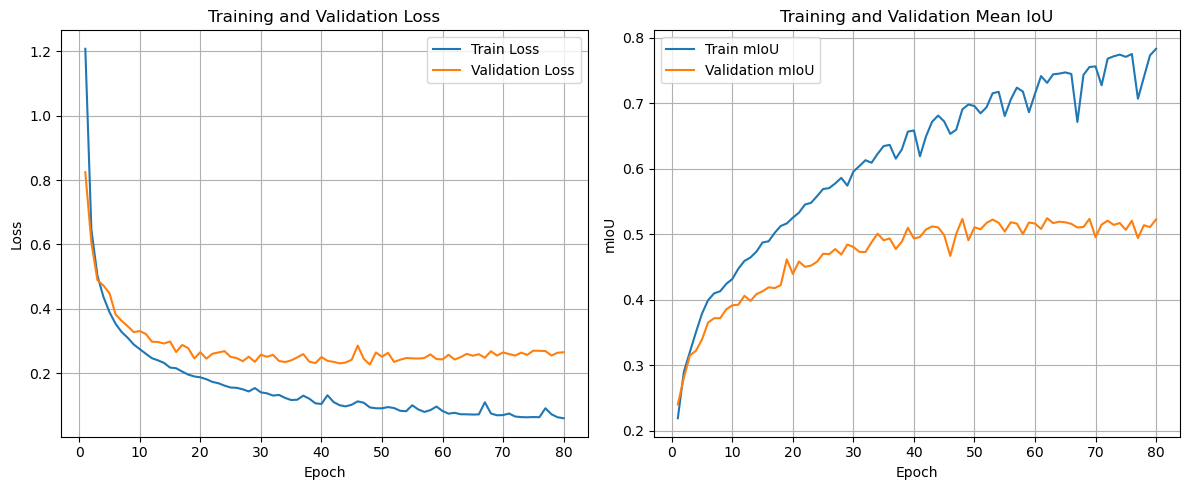

Loss and IoU plot saved to ./training_plots/unet_loss_iou_plot.png


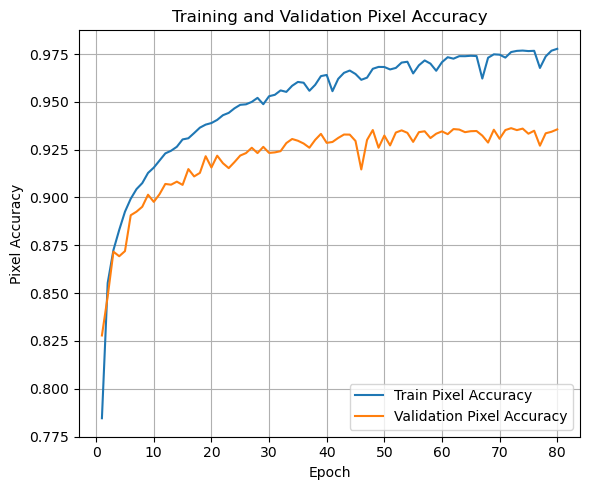

Pixel Accuracy plot saved to ./training_plots/unet_accuracy_plot.png


In [ ]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# Metric Calculation Function 
def calculate_metrics(predictions, targets, num_classes, ignore_index):
    """
    Calculates mean IoU and pixel accuracy for semantic segmentation.
    """
    predictions = predictions.argmax(dim=1)
    valid_mask = (targets != ignore_index)
    predictions = predictions.flatten()
    targets = targets.flatten()
    valid_mask = valid_mask.flatten()
    predictions = predictions[valid_mask]
    targets = targets[valid_mask]
    if targets.numel() == 0:
        return 0.0, 0.0

    correct_pixels = (predictions == targets).sum().item()
    total_pixels = targets.numel()
    pixel_accuracy = correct_pixels / total_pixels if total_pixels > 0 else 0.0

    iou_per_class = []
    for cls_id in range(num_classes):
        if cls_id == ignore_index:
            continue
        intersection = ((predictions == cls_id) & (targets == cls_id)).sum().item()
        union = ((predictions == cls_id) | (targets == cls_id)).sum().item()
        if union == 0:
            iou_per_class.append(np.nan)
        else:
            iou_per_class.append(intersection / union)
    valid_ious = [iou for iou in iou_per_class if not np.isnan(iou)]
    mean_iou = np.mean(valid_ious) if valid_ious else 0.0
    return mean_iou, pixel_accuracy

# Training and Validation Helper Functions 
def train_epoch(model, dataloader, criterion, optimizer, scaler, device, num_classes):
    model.train()
    running_loss = 0.0
    total_iou = 0.0
    total_pixel_acc = 0.0
    data_loader_iter = tqdm(dataloader, desc="Training")
    for batch_idx, (images, masks) in enumerate(data_loader_iter):
        images = images.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
        batch_iou, batch_pixel_acc = calculate_metrics(outputs.detach().cpu(), masks.cpu(), num_classes, IGNORE_INDEX)
        total_iou += batch_iou
        total_pixel_acc += batch_pixel_acc
    avg_loss = running_loss / len(dataloader)
    avg_iou = total_iou / len(dataloader)
    avg_pixel_acc = total_pixel_acc / len(dataloader)
    return avg_loss, avg_iou, avg_pixel_acc

def validate_epoch(model, dataloader, criterion, device, num_classes):
    model.eval()
    running_loss = 0.0
    total_iou = 0.0
    total_pixel_acc = 0.0
    data_loader_iter = tqdm(dataloader, desc="Validation")
    with torch.no_grad():
        for images, masks in data_loader_iter:
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            running_loss += loss.item()
            batch_iou, batch_pixel_acc = calculate_metrics(outputs.cpu(), masks.cpu(), num_classes, IGNORE_INDEX)
            total_iou += batch_iou
            total_pixel_acc += batch_pixel_acc
    avg_loss = running_loss / len(dataloader)
    avg_iou = total_iou / len(dataloader)
    avg_pixel_acc = total_pixel_acc / len(dataloader)
    return avg_loss, avg_iou, avg_pixel_acc

# Main Training Loop and Metrics Plotting 
train_losses = []
val_losses = []
train_ious = []
val_ious = []
train_accs = []
val_accs = []

best_val_iou = -1.0
best_epoch = -1

print("Starting training...")
for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start_time = time.time()
    print(f"\n--- UNet Epoch {epoch}/{NUM_EPOCHS} ---")
    train_loss, train_iou, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, scaler, DEVICE, NUM_CITYSCAPES_CLASSES
    )
    train_losses.append(train_loss)
    train_ious.append(train_iou)
    train_accs.append(train_acc)
    print(f"UNet Train Loss: {train_loss:.4f}, Train mIoU: {train_iou:.4f}, Train Pixel Acc: {train_acc:.4f}")

    val_loss, val_iou, val_acc = validate_epoch(
        model, val_loader, criterion, DEVICE, NUM_CITYSCAPES_CLASSES
    )
    val_losses.append(val_loss)
    val_ious.append(val_iou)
    val_accs.append(val_acc)
    print(f"UNet Val Loss: {val_loss:.4f}, Val mIoU: {val_iou:.4f}, Val Pixel Acc: {val_acc:.4f}")

    if val_iou > best_val_iou:
        best_val_iou = val_iou
        best_epoch = epoch
        model_save_path = os.path.join(MODEL_SAVE_DIR, 'best_unet_model.pth')
        torch.save(model.state_dict(), model_save_path)
        print(f"Saved best UNet model with Val mIoU: {best_val_iou:.4f} at epoch {best_epoch}")
    epoch_end_time = time.time()
    epoch_duration = epoch_end_time - epoch_start_time
    print(f"UNet Epoch {epoch} completed in {epoch_duration:.2f} seconds.")

print("\nTraining finished!")
print(f"Best validation mIoU: {best_val_iou:.4f} at Epoch {best_epoch}")

# Plotting Results

os.makedirs(PLOTS_SAVE_DIR, exist_ok=True)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Train Loss')
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, NUM_EPOCHS + 1), train_ious, label='Train mIoU')
plt.plot(range(1, NUM_EPOCHS + 1), val_ious, label='Validation mIoU')
plt.xlabel('Epoch')
plt.ylabel('mIoU')
plt.title('Training and Validation Mean IoU')
plt.legend()
plt.grid(True)

plt.tight_layout()
loss_iou_plot_path = os.path.join(PLOTS_SAVE_DIR, 'unet_loss_iou_plot.png')
plt.savefig(loss_iou_plot_path)
plt.show()
print(f"Loss and IoU plot saved to {loss_iou_plot_path}")

plt.figure(figsize=(6, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_accs, label='Train Pixel Accuracy')
plt.plot(range(1, NUM_EPOCHS + 1), val_accs, label='Validation Pixel Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Pixel Accuracy')
plt.title('Training and Validation Pixel Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
accuracy_plot_path = os.path.join(PLOTS_SAVE_DIR, 'unet_accuracy_plot.png')
plt.savefig(accuracy_plot_path)
plt.show()
print(f"Pixel Accuracy plot saved to {accuracy_plot_path}")


### Evaluation and Visualization


--- Starting Evaluation ---
Loading best model from ./saved_models/best_unet_model.pth
Model loaded successfully.

Running final evaluation on the validation set...


Validation: 100%|██████████| 63/63 [00:34<00:00,  1.83it/s]



Final Validation Loss: 0.2425
Final Validation mIoU: 0.5247
Final Validation Pixel Accuracy: 0.9358

Generating sample predictions and visualizations...


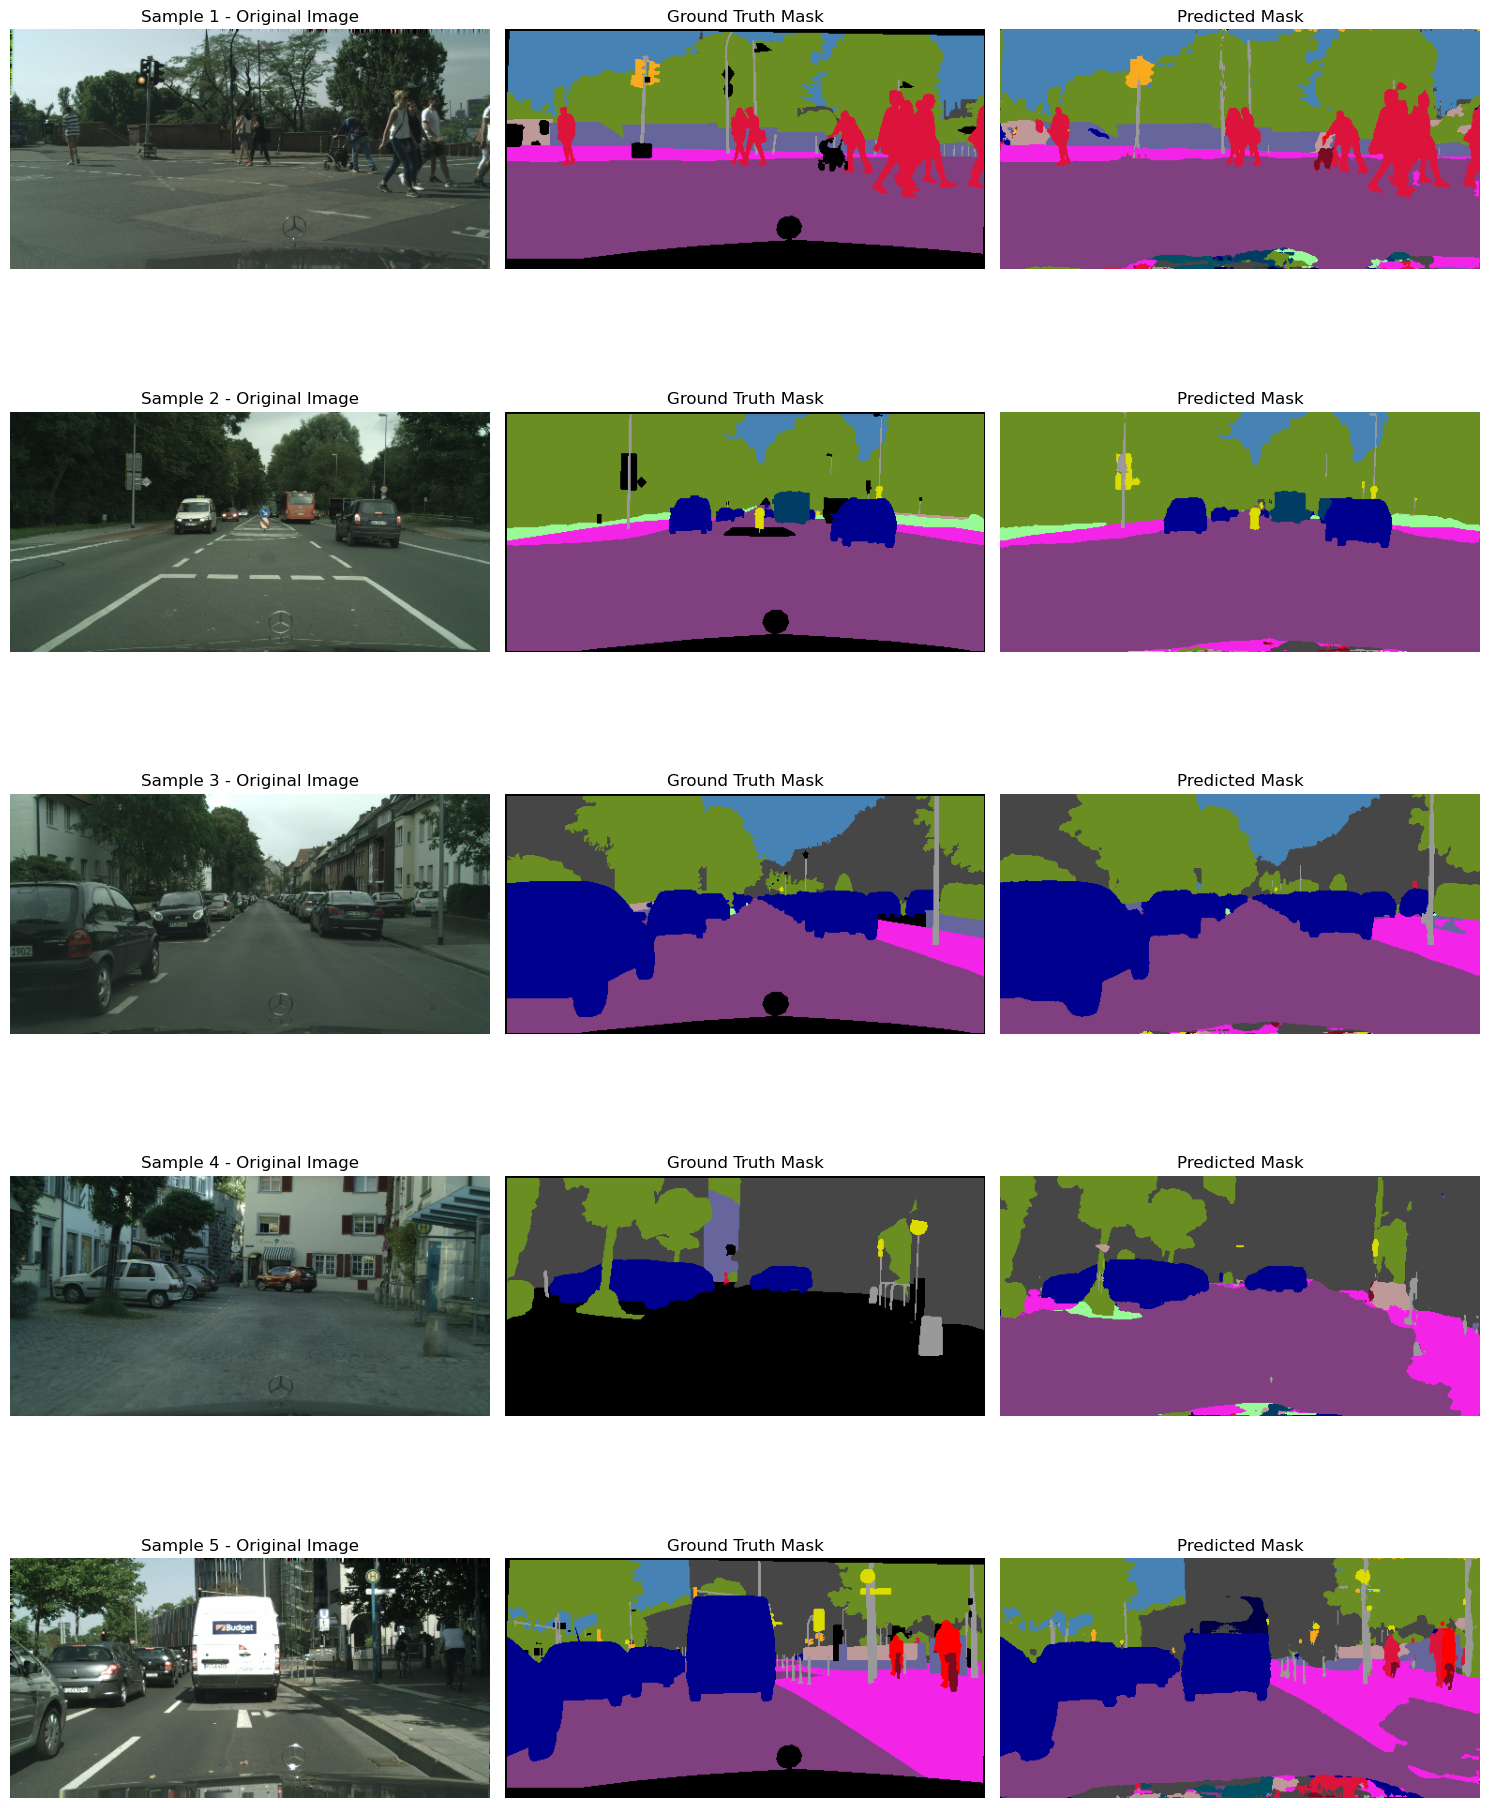

Sample predictions plot saved to ./training_plots/unet_sample_predictions.png

Evaluation complete.


In [ ]:


print("\n--- Starting Evaluation ---")

# Load the best saved model
model_path = os.path.join(MODEL_SAVE_DIR, 'best_unet_model.pth')
if os.path.exists(model_path):
    print(f"Loading best model from {model_path}")
    # Initialize the model first, then load state_dict
    evaluation_model = UNet(n_channels=3, n_classes=NUM_CITYSCAPES_CLASSES)
    evaluation_model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    evaluation_model.to(DEVICE)
    evaluation_model.eval() # Set to evaluation mode
    print("Model loaded successfully.")
else:
    print(f"ERROR: No best model found at {model_path}. Please ensure training completed successfully.")
    exit() # Exit if no model to evaluate

# Run evaluation on the validation set to get final metrics
print("\nRunning final evaluation on the validation set...")
final_val_loss, final_val_iou, final_val_acc = validate_epoch(
    evaluation_model, val_loader, criterion, DEVICE, NUM_CITYSCAPES_CLASSES
)
print(f"\nFinal Validation Loss: {final_val_loss:.4f}")
print(f"Final Validation mIoU: {final_val_iou:.4f}")
print(f"Final Validation Pixel Accuracy: {final_val_acc:.4f}")

# Visualize a few predictions
print("\nGenerating sample predictions and visualizations...")

# Get a few random samples from the validation dataset
num_samples_to_show = 5 
sample_indices = random.sample(range(len(val_dataset)), min(num_samples_to_show, len(val_dataset)))

plt.figure(figsize=(15, num_samples_to_show * 4)) 


CITYSCAPES_COLORS = np.array([
    [128, 64, 128], # 0: road
    [244, 35, 232], # 1: sidewalk
    [70, 70, 70],   # 2: building
    [102, 102, 156],# 3: wall
    [190, 153, 153],# 4: fence
    [153, 153, 153],# 5: pole
    [250, 170, 30], # 6: traffic light
    [220, 220, 0],  # 7: traffic sign
    [107, 142, 35], # 8: vegetation
    [152, 251, 152],# 9: terrain
    [70, 130, 180], # 10: sky
    [220, 20, 60],  # 11: person
    [255, 0, 0],    # 12: rider
    [0, 0, 142],    # 13: car
    [0, 0, 70],     # 14: truck
    [0, 60, 100],   # 15: bus
    [0, 80, 100],   # 16: train
    [0, 0, 230],    # 17: motorcycle
    [119, 11, 32]   # 18: bicycle
], dtype=np.uint8)

def visualize_segmentation(image, mask, pred_mask, class_colors, ignore_index):
    """
    Helper function to visualize an image, ground truth mask, and predicted mask.
    Args:
        image (np.array): Input image (H, W, C), expected normalized (undo normalization for display).
        mask (np.array): Ground truth mask (H, W), with class IDs.
        pred_mask (np.array): Predicted mask (H, W), with class IDs.
        class_colors (np.array): (N_CLASSES, 3) array of RGB colors.
        ignore_index (int): Value in mask/pred_mask to be ignored (e.g., set to black).
    """
    
    image_display = image.permute(1, 2, 0).cpu().numpy() 
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image_display = (image_display * std + mean) * 255.0
    image_display = np.clip(image_display, 0, 255).astype(np.uint8)

    # Convert masks to colored images
    colored_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    colored_pred_mask = np.zeros((*pred_mask.shape, 3), dtype=np.uint8)

    for class_id in range(len(class_colors)):
        # Apply color for valid classes
        colored_mask[mask == class_id] = class_colors[class_id]
        colored_pred_mask[pred_mask == class_id] = class_colors[class_id]

    colored_mask[mask == ignore_index] = [0, 0, 0] 
    

    return image_display, colored_mask, colored_pred_mask

for i, idx in enumerate(sample_indices):
    image, mask = val_dataset[idx] 

    # Add batch dimension and move to device for model inference
    input_image = image.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = evaluation_model(input_image)
    
    # Get predicted mask (argmax across class dimension)
    predicted_mask = output.argmax(dim=1).squeeze(0).cpu().numpy() 

    # Plotting
    ax = plt.subplot(num_samples_to_show, 3, i * 3 + 1)
    img_display, gt_mask_display, pred_mask_display = visualize_segmentation(
        image, mask.cpu().numpy(), predicted_mask, CITYSCAPES_COLORS, IGNORE_INDEX
    )
    
    ax.imshow(img_display)
    ax.set_title(f'Sample {i+1} - Original Image')
    ax.axis('off')

    ax = plt.subplot(num_samples_to_show, 3, i * 3 + 2)
    ax.imshow(gt_mask_display)
    ax.set_title('Ground Truth Mask')
    ax.axis('off')

    ax = plt.subplot(num_samples_to_show, 3, i * 3 + 3)
    ax.imshow(pred_mask_display)
    ax.set_title('Predicted Mask')
    ax.axis('off')

plt.tight_layout()
visualization_plot_path = os.path.join(PLOTS_SAVE_DIR, 'unet_sample_predictions.png')
plt.savefig(visualization_plot_path)
plt.show()
print(f"Sample predictions plot saved to {visualization_plot_path}")

print("\nEvaluation complete.")

# Segnet

### Configuration Parameters

In [ ]:
import torch
import numpy as np
import os
import warnings


#  Global Configuration Parameters 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_HEIGHT = 256
IMAGE_WIDTH = 512
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
NUM_EPOCHS = 80
NUM_CITYSCAPES_CLASSES = 19 
IGNORE_INDEX = 255 

# Define the ID_TO_TRAINID mapping for Cityscapes
ID_TO_TRAINID = np.full(256, 255, dtype=np.uint8)
ID_TO_TRAINID[[7, 8, 11, 12, 13, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 31, 32, 33]] = \
    [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]

# Cityscapes training class names 
CITYSCAPES_CLASS_NAMES = [
    "road", "sidewalk", "building", "wall", "fence", "pole", "traffic light",
    "traffic sign", "vegetation", "terrain", "sky", "person", "rider", "car",
    "truck", "bus", "train", "motorcycle", "bicycle"
]

# PATH CONFIGURATION
TRAIN_IMAGES_DIR = './leftImg8bit_trainvaltest/leftImg8bit/train'
TRAIN_MASKS_DIR = './gtFine_trainvaltest/gtFine/train'
VAL_IMAGES_DIR = './leftImg8bit_trainvaltest/leftImg8bit/val'
VAL_MASKS_DIR = './gtFine_trainvaltest/gtFine/val'

# Directories for saving models and plots
MODEL_SAVE_DIR = './saved_models'
PLOTS_SAVE_DIR = './training_plots'

# Create necessary directories if they don't exist
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(PLOTS_SAVE_DIR, exist_ok=True)

print(f"Configuration loaded. Device: {DEVICE}")
print(f"Image dimensions: {IMAGE_HEIGHT}x{IMAGE_WIDTH}")
print(f"Number of Cityscapes classes (train IDs): {NUM_CITYSCAPES_CLASSES}")
print(f"Training Image Dir: {TRAIN_IMAGES_DIR}")
print(f"Training Mask Dir: {TRAIN_MASKS_DIR}")
print(f"Validation Image Dir: {VAL_IMAGES_DIR}")
print(f"Validation Mask Dir: {VAL_MASKS_DIR}")

#  CRITICAL PATH DIAGNOSTICS 
print("\n--- Running initial path diagnostics ---")

example_train_city_dir = os.path.join(TRAIN_IMAGES_DIR, 'aachen')
if not os.path.exists(example_train_city_dir):
    print(f"WARNING: Example train city directory '{example_train_city_dir}' not found.")
    print("This might indicate an issue with your data path or structure.")
    print("Please ensure your Cityscapes data is extracted correctly.")

print("All base image and mask directories confirmed to exist.")
print("--- End of initial path diagnostics ---")

Configuration parameters for Cityscapes training.
Configuration loaded. Device: cuda
Image dimensions: 256x512
Number of Cityscapes classes (train IDs): 19
Training Image Dir: ./leftImg8bit_trainvaltest/leftImg8bit/train
Training Mask Dir: ./gtFine_trainvaltest/gtFine/train
Validation Image Dir: ./leftImg8bit_trainvaltest/leftImg8bit/val
Validation Mask Dir: ./gtFine_trainvaltest/gtFine/val

--- Running initial path diagnostics ---
All base image and mask directories confirmed to exist.
--- End of initial path diagnostics ---


In [ ]:
# Cell 2: Dataset and DataLoader Definition (Content of dataset.py - CORRECTED)

import os
import cv2
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2


class CityscapesDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None, debug_mode=False):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform
        self.debug_mode = debug_mode 
        self.image_files = self._get_image_files()

        if not self.image_files:
            raise RuntimeError(
                f"No image files found in '{images_dir}'. "
                f"Please ensure images exist and are named '*_leftImg8bit.png' "
                f"within city subfolders (e.g., '{images_dir}/aachen/*.png')."
            )
        print(f"Found {len(self.image_files)} image files for this split.")


    def _get_image_files(self):
        image_files = []
        if not os.path.isdir(self.images_dir):
            raise FileNotFoundError(f"Image directory does not exist: {self.images_dir}")

        for city_folder in sorted(os.listdir(self.images_dir)):
            city_path = os.path.join(self.images_dir, city_folder)
            
            if os.path.isdir(city_path):
                current_city_images = sorted([f for f in os.listdir(city_path) if f.endswith('_leftImg8bit.png')])
                for img_name in current_city_images:
                    image_files.append(os.path.join(city_path, img_name))
        return image_files

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        
        city_folder = os.path.basename(os.path.dirname(img_path))
        base_filename = os.path.basename(img_path).replace('_leftImg8bit.png', '')
        
        mask_name = f"{base_filename}_gtFine_labelIds.png"
        mask_path = os.path.join(self.masks_dir, city_folder, mask_name)

        if not os.path.exists(mask_path):
            raise FileNotFoundError(
                f"Mask file not found for image '{os.path.basename(img_path)}' at '{mask_path}'. "
                f"This indicates a potential data corruption or naming mismatch. "
                f"Image: '{img_path}'"
            )

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 

        raw_mask = np.array(Image.open(mask_path), dtype=np.uint8)

        if self.debug_mode:
            unique_raw_mask_values = np.unique(raw_mask)
            if unique_raw_mask_values.min() < 0 or unique_raw_mask_values.max() > 255:
                print(f"DEBUG WARNING: Raw mask {mask_path} contains values outside [0, 255]: {unique_raw_mask_values}")

        mask = ID_TO_TRAINID[raw_mask]

        if self.debug_mode:
            unique_mapped_mask_values = np.unique(mask)
            # NUM_CITYSCAPES_CLASSES 
            invalid_mapped_values = [v for v in unique_mapped_mask_values if (v < 0 or v >= NUM_CITYSCAPES_CLASSES) and v != IGNORE_INDEX]
            if invalid_mapped_values:
                print(f"DEBUG ERROR: Mapped mask {mask_path} contains invalid target values: {invalid_mapped_values}")
                print(f"DEBUG Expected range: [0, {NUM_CITYSCAPES_CLASSES-1}] or {IGNORE_INDEX} (ignore_index)")
                raise ValueError(f"Invalid mapped mask values found in {mask_path}: {invalid_mapped_values}. Expected range: [0, {NUM_CITYSCAPES_CLASSES-1}] or {IGNORE_INDEX} (ignore_index).")

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        
        return image, mask.long()

# Define Albumentations Transforms
train_transform = A.Compose([
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH, interpolation=cv2.INTER_NEAREST),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH, interpolation=cv2.INTER_NEAREST),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0),
    ToTensorV2(),
])

print("CityscapesDataset class and transforms defined.")

CityscapesDataset class and transforms defined.


### SegNet Model Architecture

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SegNetEncoderBlock(nn.Module):
    """
    SegNet Encoder Block:
    Consists of multiple Conv2d -> BatchNorm2d -> ReLU layers,
    followed by a MaxPool2d layer which returns indices.
    """
    def __init__(self, in_channels, out_channels, num_conv_layers):
        super(SegNetEncoderBlock, self).__init__()
        layers = []
        layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
        layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))

        for _ in range(num_conv_layers - 1):
            layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1))
            layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.ReLU(inplace=True))
        
        self.encode = nn.Sequential(*layers)

    def forward(self, x):
       
        return self.encode(x)


class SegNetDecoderBlock(nn.Module):
    """
    SegNet Decoder Block:
    Consists of an MaxUnpool2d layer (using indices from encoder),
    followed by multiple Conv2d -> BatchNorm2d -> ReLU layers.
    """
    def __init__(self, in_channels, out_channels, num_conv_layers):
        super(SegNetDecoderBlock, self).__init__()
        layers = []
        
        for _ in range(num_conv_layers - 1):
            layers.append(nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1))
            layers.append(nn.BatchNorm2d(in_channels))
            layers.append(nn.ReLU(inplace=True))

        layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
        layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))

        self.decode = nn.Sequential(*layers)

    def forward(self, x):
        return self.decode(x)


class SegNet(nn.Module):
    def __init__(self, n_channels, n_classes):
        super(SegNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes

        # Encoder Block 1
        self.enc1 = SegNetEncoderBlock(n_channels, 64, num_conv_layers=2)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)

        # Encoder Block 2
        self.enc2 = SegNetEncoderBlock(64, 128, num_conv_layers=2)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)

        # Encoder Block 3
        self.enc3 = SegNetEncoderBlock(128, 256, num_conv_layers=3)
        self.maxpool3 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)

        # Encoder Block 4
        self.enc4 = SegNetEncoderBlock(256, 512, num_conv_layers=3)
        self.maxpool4 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)

        # Encoder Block 5 (often referred to as the bottleneck or bridge)
        self.enc5 = SegNetEncoderBlock(512, 512, num_conv_layers=3)
        self.maxpool5 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)
        
        # Decoder Block 5
        self.dec5 = SegNetDecoderBlock(512, 512, num_conv_layers=3)
        self.unpool5 = nn.MaxUnpool2d(kernel_size=2, stride=2)

        # Decoder Block 4
        self.dec4 = SegNetDecoderBlock(512, 256, num_conv_layers=3)
        self.unpool4 = nn.MaxUnpool2d(kernel_size=2, stride=2)

        # Decoder Block 3
        self.dec3 = SegNetDecoderBlock(256, 128, num_conv_layers=3)
        self.unpool3 = nn.MaxUnpool2d(kernel_size=2, stride=2)

        # Decoder Block 2
        self.dec2 = SegNetDecoderBlock(128, 64, num_conv_layers=2)
        self.unpool2 = nn.MaxUnpool2d(kernel_size=2, stride=2)

        # Decoder Block 1
        self.dec1 = SegNetDecoderBlock(64, 64, num_conv_layers=2) # Output 64 channels
        self.unpool1 = nn.MaxUnpool2d(kernel_size=2, stride=2)

        # Final Convolutional Layer (Classifier)
        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)


    def forward(self, x):
        # Encoder Path
        enc1, indices1 = self.maxpool1(self.enc1(x))
        enc2, indices2 = self.maxpool2(self.enc2(enc1))
        enc3, indices3 = self.maxpool3(self.enc3(enc2))
        enc4, indices4 = self.maxpool4(self.enc4(enc3))
        enc5, indices5 = self.maxpool5(self.enc5(enc4))

        # Store sizes for unpooling (essential for MaxUnpool2d)
        size1 = enc1.size()
        size2 = enc2.size()
        size3 = enc3.size()
        size4 = enc4.size()
        # size5 is just enc5.size(), used implicitly by unpool5

        # Decoder Path
        dec5 = self.unpool5(enc5, indices5, output_size=size4)
        dec5 = self.dec5(dec5)

        dec4 = self.unpool4(dec5, indices4, output_size=size3)
        dec4 = self.dec4(dec4)

        dec3 = self.unpool3(dec4, indices3, output_size=size2)
        dec3 = self.dec3(dec3)

        dec2 = self.unpool2(dec3, indices2, output_size=size1)
        dec2 = self.dec2(dec2)

        # The first decoder block directly uses the output of unpool1
        dec1 = self.unpool1(dec2, indices1, output_size=x.size()) 
        dec1 = self.dec1(dec1)

        # Final output convolution
        logits = self.outc(dec1)
        return logits

print("SegNet model architecture defined.")

SegNet model architecture defined.


### Metric Calculation Functions 

In [ ]:
# Cell 4: 

import torch
import numpy as np



def calculate_metrics(predictions, targets, num_classes, ignore_index):

    predictions = predictions.argmax(dim=1)
    
    valid_mask = (targets != ignore_index)
    
    predictions = predictions.flatten()
    targets = targets.flatten()
    valid_mask = valid_mask.flatten()

    predictions = predictions[valid_mask]
    targets = targets[valid_mask]
    
    if targets.numel() == 0:
        return 0.0, 0.0

    # Pixel Accuracy
    correct_pixels = (predictions == targets).sum().item()
    total_pixels = targets.numel()
    pixel_accuracy = correct_pixels / total_pixels if total_pixels > 0 else 0.0

    # Mean IoU
    iou_per_class = []
    for cls_id in range(num_classes):
        if cls_id == ignore_index:
            continue
        
        intersection = ((predictions == cls_id) & (targets == cls_id)).sum().item()
        union = ((predictions == cls_id) | (targets == cls_id)).sum().item()
        
        if union == 0:
            iou_per_class.append(np.nan) 
        else:
            iou_per_class.append(intersection / union)
            
    valid_ious = [iou for iou in iou_per_class if not np.isnan(iou)]
    mean_iou = np.mean(valid_ious) if valid_ious else 0.0

    return mean_iou, pixel_accuracy

# Optional: if you still need these standalone functions, keep them.
def calculate_iou_old(pred, target, num_classes, ignore_index):
    pred = torch.argmax(pred, dim=1)
    valid_pixels = (target != ignore_index)
    pred_flat = pred[valid_pixels].flatten()
    target_flat = target[valid_pixels].flatten()

    iou_list = []
    for cls_id in range(num_classes):
        pred_mask_cls = (pred_flat == cls_id)
        target_mask_cls = (target_flat == cls_id)
        intersection = (pred_mask_cls & target_mask_cls).sum().item()
        union = (pred_mask_cls | target_mask_cls).sum().item()
        if union == 0:
            iou = float('nan')
        else:
            iou = intersection / union
        iou_list.append(iou)
    valid_ious = [iou for iou in iou_list if not np.isnan(iou)]
    return np.mean(valid_ious) if valid_ious else 0.0, iou_list

def calculate_pixel_accuracy_old(pred, target, ignore_index):
    pred = torch.argmax(pred, dim=1)
    valid_pixels = (target != ignore_index)
    correct_pixels = (pred == target) & valid_pixels
    total_valid_pixels = valid_pixels.sum().item()
    total_correct_pixels = correct_pixels.sum().item()
    return total_correct_pixels / total_valid_pixels if total_valid_pixels > 0 else 0.0


print("Metric calculation functions defined.")

Metric calculation functions defined.


### Main Training, Evaluation, and Visualization

All necessary libraries imported and preceding cells' definitions available.
Training and validation epoch functions defined.
Initializing DataLoaders...
Found 2975 image files for this split.
Found 500 image files for this split.
DataLoaders initialized: 372 training batches, 63 validation batches.
Model (SegNet) initialized and moved to: cuda


/tmp/ipykernel_1157626/2497368677.py:125: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Loss function, optimizer, and scaler initialized.
Starting training...

--- SegNet Epoch 1/80 ---


Training:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_1157626/2497368677.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Training: 100%|██████████| 372/372 [04:01<00:00,  1.54it/s]


SegNet Train Loss: 1.3846, Train mIoU: 0.1699, Train Pixel Acc: 0.7249


...

SegNet Val Loss: 0.3463, Val mIoU: 0.4201, Val Pixel Acc: 0.9112
SegNet Epoch 79 completed in 270.14 seconds.

--- SegNet Epoch 80/80 ---


Training: 100%|██████████| 372/372 [03:54<00:00,  1.58it/s]


SegNet Train Loss: 0.0922, Train mIoU: 0.6903, Train Pixel Acc: 0.9677


Validation: 100%|██████████| 63/63 [00:32<00:00,  1.91it/s]


SegNet Val Loss: 0.3655, Val mIoU: 0.4177, Val Pixel Acc: 0.9108
SegNet Epoch 80 completed in 267.67 seconds.

Training finished!
Best validation mIoU: 0.4207 at Epoch 64


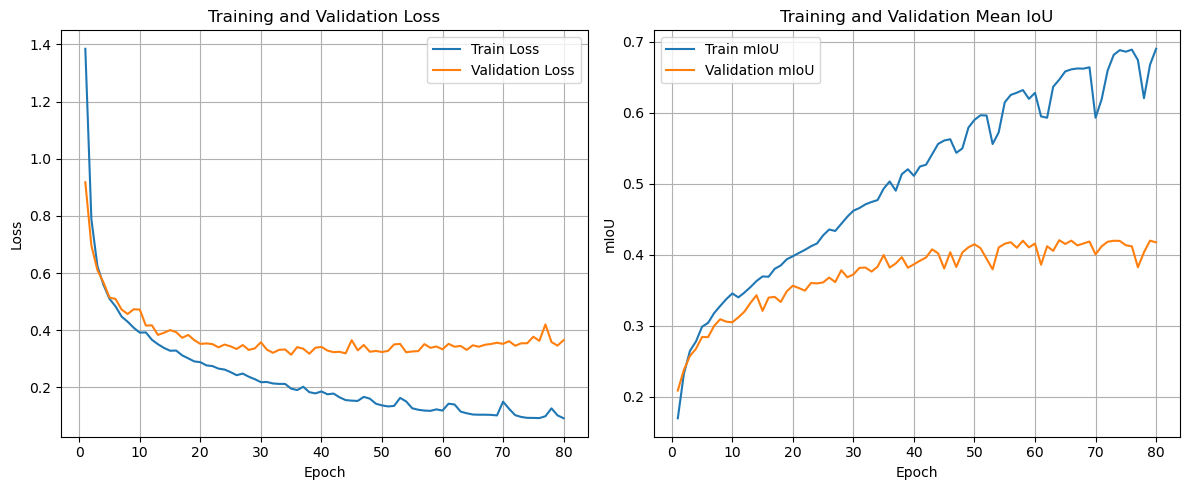

Loss and IoU plot saved to ./training_plots/segnet_loss_iou_plot.png


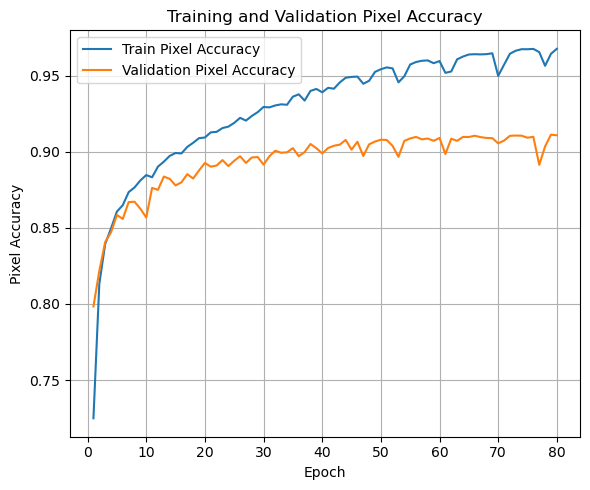

Pixel Accuracy plot saved to ./training_plots/segnet_accuracy_plot.png

--- Starting Final Evaluation and Visualization ---
Loading best SegNet model from ./saved_models/best_segnet_model.pth
Model loaded successfully.

Running final evaluation on the validation set...


Validation: 100%|██████████| 63/63 [00:32<00:00,  1.91it/s]



Final Validation Loss: 0.3313
Final Validation mIoU: 0.4207
Final Validation Pixel Accuracy: 0.9098

Generating sample predictions and visualizations...


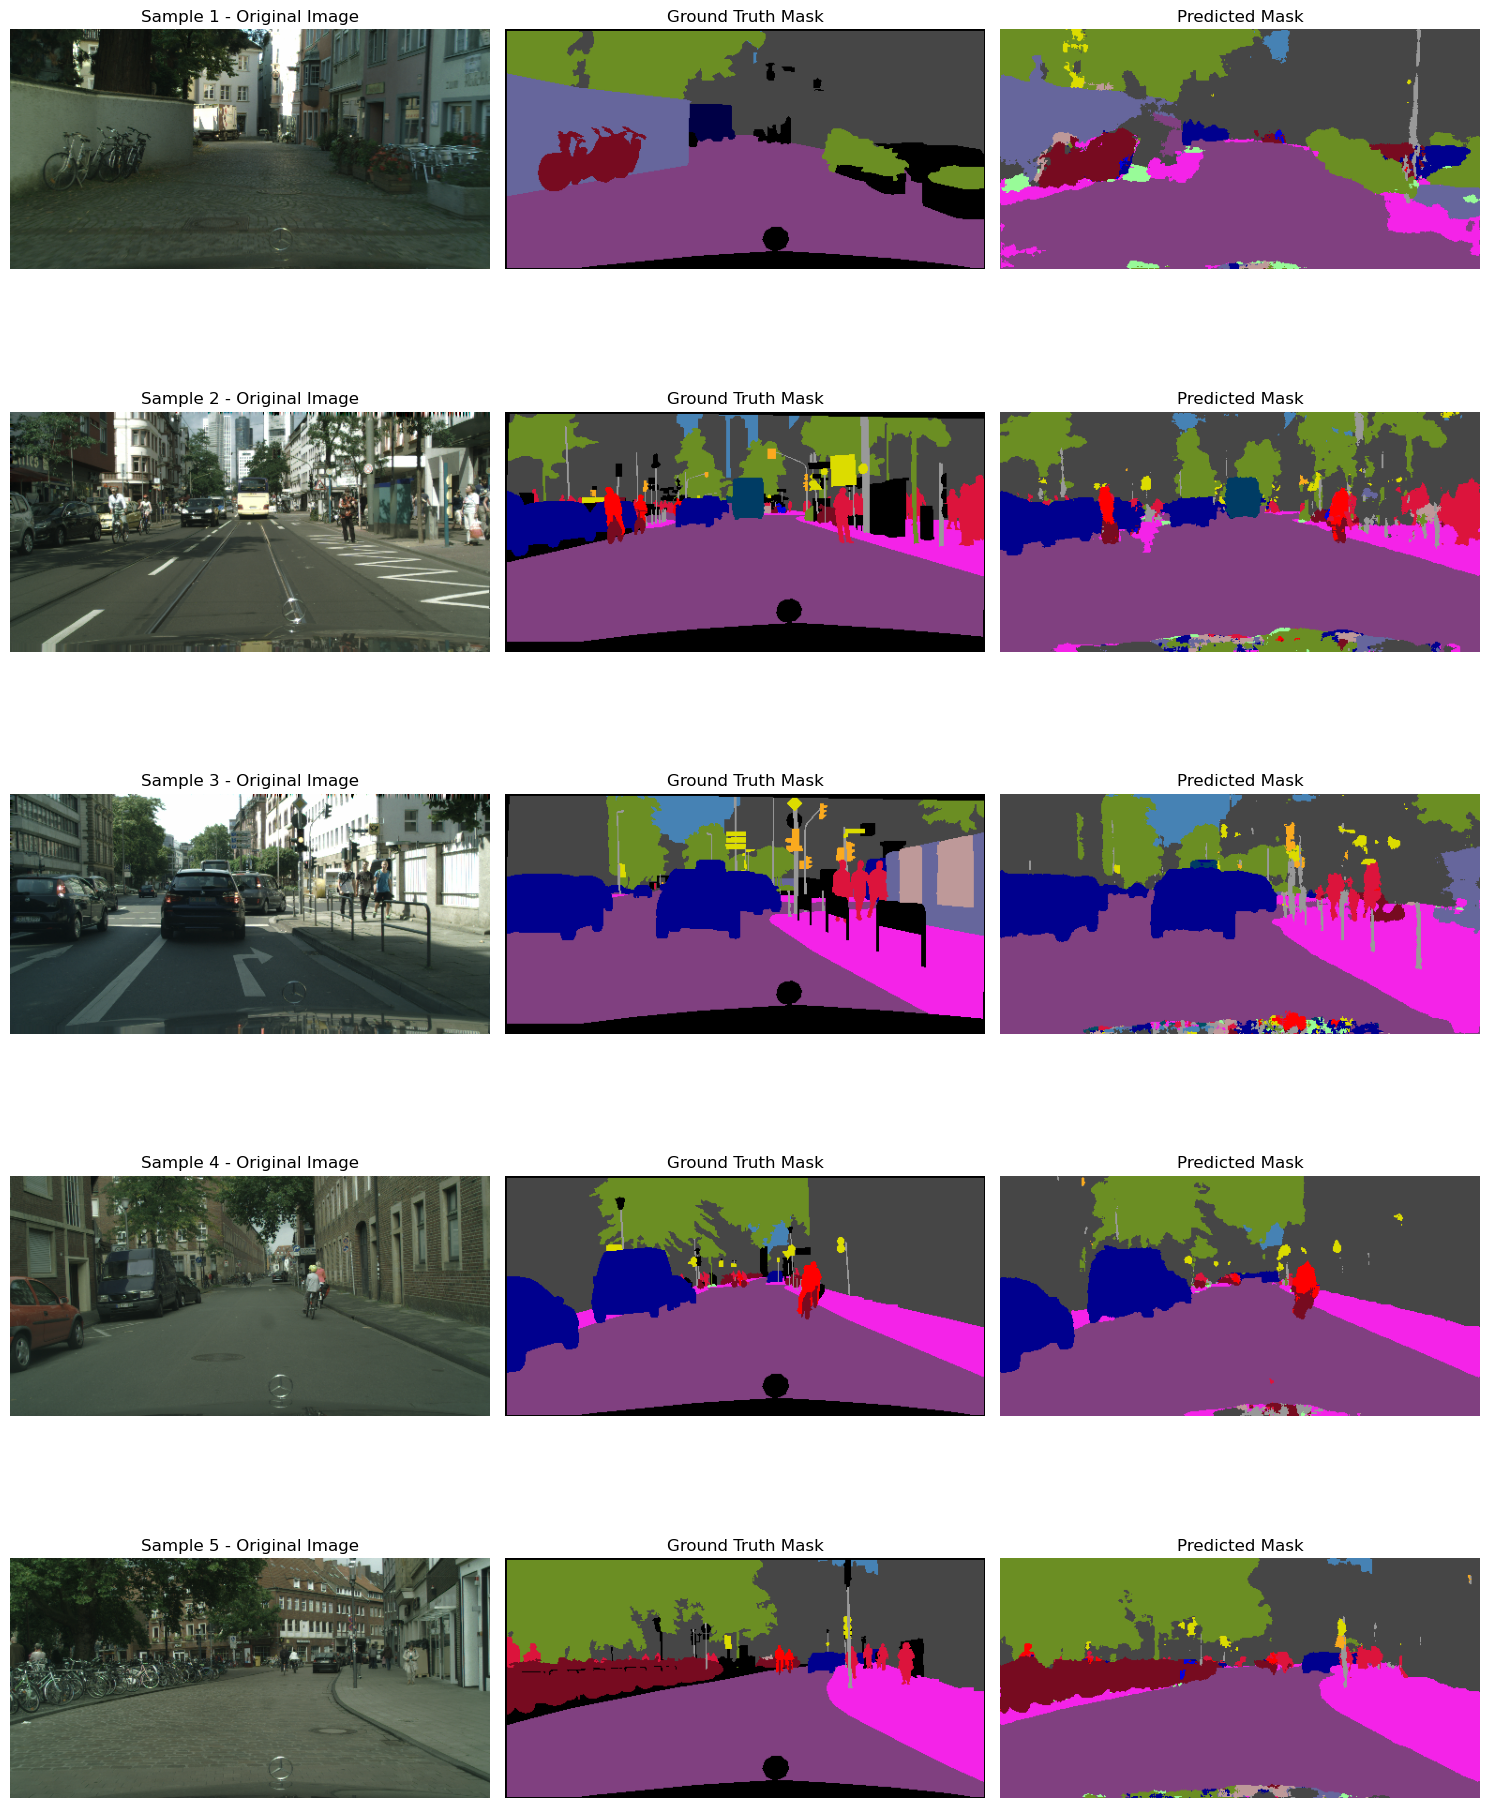

Sample predictions plot saved to ./training_plots/segnet_sample_predictions.png

Final evaluation and visualization complete.


In [ ]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import random



print("All necessary libraries imported and preceding cells' definitions available.")

# Training and Validation Helper Functions
def train_epoch(model, dataloader, criterion, optimizer, scaler, device, num_classes):
    model.train()
    running_loss = 0.0
    total_iou = 0.0
    total_pixel_acc = 0.0
    
    data_loader_iter = tqdm(dataloader, desc="Training")

    for batch_idx, (images, masks) in enumerate(data_loader_iter):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        # IGNORE_INDEX is available from the 'config' cell
        batch_iou, batch_pixel_acc = calculate_metrics(outputs.detach().cpu(), masks.cpu(), num_classes, IGNORE_INDEX)
        total_iou += batch_iou
        total_pixel_acc += batch_pixel_acc

    avg_loss = running_loss / len(dataloader)
    avg_iou = total_iou / len(dataloader)
    avg_pixel_acc = total_pixel_acc / len(dataloader)
    return avg_loss, avg_iou, avg_pixel_acc

def validate_epoch(model, dataloader, criterion, device, num_classes):
    model.eval()
    running_loss = 0.0
    total_iou = 0.0
    total_pixel_acc = 0.0

    data_loader_iter = tqdm(dataloader, desc="Validation")

    with torch.no_grad():
        for images, masks in data_loader_iter:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            running_loss += loss.item()

            # IGNORE_INDEX is available from the 'config' cell
            batch_iou, batch_pixel_acc = calculate_metrics(outputs.cpu(), masks.cpu(), num_classes, IGNORE_INDEX)
            total_iou += batch_iou
            total_pixel_acc += batch_pixel_acc

    avg_loss = running_loss / len(dataloader)
    avg_iou = total_iou / len(dataloader)
    avg_pixel_acc = total_pixel_acc / len(dataloader)
    return avg_loss, avg_iou, avg_pixel_acc

print("Training and validation epoch functions defined.")


# --- Model, Loss, Optimizer, Scaler Initialization ---
print("Initializing DataLoaders...")
try:
   
    train_dataset = CityscapesDataset(images_dir=TRAIN_IMAGES_DIR, masks_dir=TRAIN_MASKS_DIR, transform=train_transform, debug_mode=False)
    val_dataset = CityscapesDataset(images_dir=VAL_IMAGES_DIR, masks_dir=VAL_MASKS_DIR, transform=val_transform, debug_mode=False)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count() // 2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count() // 2, pin_memory=True)
    
    print(f"DataLoaders initialized: {len(train_loader)} training batches, {len(val_loader)} validation batches.")

# Select SegNet model

model = SegNet(n_channels=3, n_classes=NUM_CITYSCAPES_CLASSES) 
model.to(DEVICE)
print(f"Model ({model.__class__.__name__}) initialized and moved to: {DEVICE}")

criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scaler = GradScaler() 

print("Loss function, optimizer, and scaler initialized.")


# Main Training Loop 
train_losses = []
val_losses = []
train_ious = []
val_ious = []
train_accs = []
val_accs = []

best_val_iou = -1.0
best_epoch = -1

print("Starting training...")
for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start_time = time.time()
    print(f"\n--- {model.__class__.__name__} Epoch {epoch}/{NUM_EPOCHS} ---")

    train_loss, train_iou, train_acc = train_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE, NUM_CITYSCAPES_CLASSES)
    train_losses.append(train_loss)
    train_ious.append(train_iou)
    train_accs.append(train_acc)
    print(f"{model.__class__.__name__} Train Loss: {train_loss:.4f}, Train mIoU: {train_iou:.4f}, Train Pixel Acc: {train_acc:.4f}")

    val_loss, val_iou, val_acc = validate_epoch(model, val_loader, criterion, DEVICE, NUM_CITYSCAPES_CLASSES)
    val_losses.append(val_loss)
    val_ious.append(val_iou)
    val_accs.append(val_acc)
    print(f"{model.__class__.__name__} Val Loss: {val_loss:.4f}, Val mIoU: {val_iou:.4f}, Val Pixel Acc: {val_acc:.4f}")

    # Save best model based on validation IoU
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        best_epoch = epoch
        model_save_path = os.path.join(MODEL_SAVE_DIR, f'best_{model.__class__.__name__.lower()}_model.pth')
        torch.save(model.state_dict(), model_save_path)
        print(f"Saved best {model.__class__.__name__} model with Val mIoU: {best_val_iou:.4f} at epoch {best_epoch}")
    
    epoch_end_time = time.time()
    epoch_duration = epoch_end_time - epoch_start_time
    print(f"{model.__class__.__name__} Epoch {epoch} completed in {epoch_duration:.2f} seconds.")

print("\nTraining finished!")
print(f"Best validation mIoU: {best_val_iou:.4f} at Epoch {best_epoch}")

#  Plotting Results 

os.makedirs(PLOTS_SAVE_DIR, exist_ok=True)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Train Loss')
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, NUM_EPOCHS + 1), train_ious, label='Train mIoU')
plt.plot(range(1, NUM_EPOCHS + 1), val_ious, label='Validation mIoU')
plt.xlabel('Epoch')
plt.ylabel('mIoU')
plt.title('Training and Validation Mean IoU')
plt.legend()
plt.grid(True)

plt.tight_layout()
loss_iou_plot_path = os.path.join(PLOTS_SAVE_DIR, f'{model.__class__.__name__.lower()}_loss_iou_plot.png')
plt.savefig(loss_iou_plot_path)
plt.show()
print(f"Loss and IoU plot saved to {loss_iou_plot_path}")

plt.figure(figsize=(6, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_accs, label='Train Pixel Accuracy')
plt.plot(range(1, NUM_EPOCHS + 1), val_accs, label='Validation Pixel Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Pixel Accuracy')
plt.title('Training and Validation Pixel Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
accuracy_plot_path = os.path.join(PLOTS_SAVE_DIR, f'{model.__class__.__name__.lower()}_accuracy_plot.png')
plt.savefig(accuracy_plot_path)
plt.show()
print(f"Pixel Accuracy plot saved to {accuracy_plot_path}")


# Evaluation and Visualization
print("\n--- Starting Final Evaluation and Visualization ---")

MODEL_NAME = model.__class__.__name__
model_path = os.path.join(MODEL_SAVE_DIR, f'best_{MODEL_NAME.lower()}_model.pth')

if os.path.exists(model_path):
    print(f"Loading best {MODEL_NAME} model from {model_path}")
    evaluation_model = SegNet(n_channels=3, n_classes=NUM_CITYSCAPES_CLASSES) # Instantiate SegNet
    evaluation_model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    evaluation_model.to(DEVICE)
    evaluation_model.eval()
    print("Model loaded successfully.")
else:
    print(f"ERROR: No best model found at {model_path}. Please ensure training completed successfully.")

print("\nRunning final evaluation on the validation set...")
final_val_loss, final_val_iou, final_val_acc = validate_epoch(
    evaluation_model, val_loader, criterion, DEVICE, NUM_CITYSCAPES_CLASSES
)
print(f"\nFinal Validation Loss: {final_val_loss:.4f}")
print(f"Final Validation mIoU: {final_val_iou:.4f}")
print(f"Final Validation Pixel Accuracy: {final_val_acc:.4f}")

print("\nGenerating sample predictions and visualizations...")

num_samples_to_show = 5
sample_indices = random.sample(range(len(val_dataset)), min(num_samples_to_show, len(val_dataset)))

plt.figure(figsize=(15, num_samples_to_show * 4))

# CITYSCAPES_COLORS and IGNORE_INDEX 
CITYSCAPES_COLORS = np.array([
    [128, 64, 128], # 0: road
    [244, 35, 232], # 1: sidewalk
    [70, 70, 70],   # 2: building
    [102, 102, 156],# 3: wall
    [190, 153, 153],# 4: fence
    [153, 153, 153],# 5: pole
    [250, 170, 30], # 6: traffic light
    [220, 220, 0],  # 7: traffic sign
    [107, 142, 35], # 8: vegetation
    [152, 251, 152],# 9: terrain
    [70, 130, 180], # 10: sky
    [220, 20, 60],  # 11: person
    [255, 0, 0],    # 12: rider
    [0, 0, 142],    # 13: car
    [0, 0, 70],     # 14: truck
    [0, 60, 100],   # 15: bus
    [0, 80, 100],   # 16: train
    [0, 0, 230],    # 17: motorcycle
    [119, 11, 32]   # 18: bicycle
], dtype=np.uint8)

def visualize_segmentation(image, mask, pred_mask, class_colors, ignore_index):
    image_display = image.permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image_display = (image_display * std + mean) * 255.0
    image_display = np.clip(image_display, 0, 255).astype(np.uint8)

    colored_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    colored_pred_mask = np.zeros((*pred_mask.shape, 3), dtype=np.uint8)

    for class_id in range(len(class_colors)):
        colored_mask[mask == class_id] = class_colors[class_id]
        colored_pred_mask[pred_mask == class_id] = class_colors[class_id]

    colored_mask[mask == ignore_index] = [0, 0, 0]

    return image_display, colored_mask, colored_pred_mask

for i, idx in enumerate(sample_indices):
    image, mask = val_dataset[idx]

    input_image = image.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = evaluation_model(input_image)
    
    predicted_mask = output.argmax(dim=1).squeeze(0).cpu().numpy()

    ax = plt.subplot(num_samples_to_show, 3, i * 3 + 1)
    img_display, gt_mask_display, pred_mask_display = visualize_segmentation(
        image, mask.cpu().numpy(), predicted_mask, CITYSCAPES_COLORS, IGNORE_INDEX
    )
    
    ax.imshow(img_display)
    ax.set_title(f'Sample {i+1} - Original Image')
    ax.axis('off')

    ax = plt.subplot(num_samples_to_show, 3, i * 3 + 2)
    ax.imshow(gt_mask_display)
    ax.set_title('Ground Truth Mask')
    ax.axis('off')

    ax = plt.subplot(num_samples_to_show, 3, i * 3 + 3)
    ax.imshow(pred_mask_display)
    ax.set_title('Predicted Mask')
    ax.axis('off')

plt.tight_layout()
visualization_plot_path = os.path.join(PLOTS_SAVE_DIR, f'{MODEL_NAME.lower()}_sample_predictions.png')
plt.savefig(visualization_plot_path)
plt.show()
print(f"Sample predictions plot saved to {visualization_plot_path}")

print("\nFinal evaluation and visualization complete.")